In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import time
from pathlib import Path
from configurations.data import download_cluster_data , load_data , make_data_paths , make_params_dict
from configurations.plots import apply_general_styles , set_font_sizes , FONTSIZES, create_fig

apply_general_styles()

# Template

In [37]:
# Donwload data from cluster

N = 1024
N_samples = 2500
burnin = 1500
h = 0.9
perc = 80
z_th = 1.5

names = ['N','N_samples','burnin','h','perc','z_th']
params = make_params_dict(names)
path_local , filename, _ = make_data_paths('results', experiment_name='mapping', params=params,base_dir='../data')
path_cluster = './Hopfield_Dimensionality/data/mapping/' 

# print(path_local)
# # Make sure local directory exist
# Path(path_local).parent.mkdir(parents=True, exist_ok=True)
# download_cluster_data('ulysses',path_cluster,path_local,'results_N1024_N_samples2500_burnin1500_h0.9_perc85_z_th2.pkl')

# Load data
results = load_data('results', experiment_name='mapping', params=params,base_dir='../data')
print(results.keys())
for key in results.keys():
    print(f'{key}: {results[key].shape}')

File results_N1024_N_samples2500_burnin1500_h0.9_perc80_z_th1.5.pkl loaded with pickle.load from c:\Users\crise\OneDrive - SISSA\Documents\REPOS\Hopfield_Dimensionality\data\mapping
dict_keys(['means', 'stds', 'counts'])
means: (2, 31, 31, 3)
stds: (2, 31, 31, 3)
counts: (2, 31, 31)


In [12]:
data = np.load('data_transition.npy')
T_crit , a1 , a2 = data


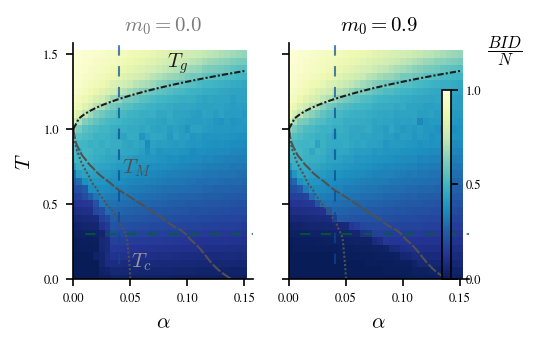

In [38]:
ncols = 2
nrows = 1

single_w = 3.4
double_w = 7.06

width = single_w
figsize= (single_w,0.6*single_w)

lbTc = [r'$T_c$',r'$T_M$',r'$T_g$']
col_crit = [plt.get_cmap('Greys')(a) for a in [0.5,0.75,0.9]]
lsts = [(0, (1, 1)),(0, (5, 1)),(0, (3, 1, 1, 1))]
tick_num = np.array([0,0.5,1.0,1.5])
cmaps = ['Blues','Greens']

alphas = np.linspace(0.01,0.16,31)
temps = np.linspace(0.1,1.6,31)
hs = [0.0,0.9]

set_font_sizes('tight')
fig , axes = plt.subplots(nrows,ncols,figsize=figsize,sharex=True,sharey=True,width_ratios=[1,1])



lbTc = [r'$T_c$',r'$T_M$',r'$T_g$']
T_star = 0.3
a_star = 0.04
tick_num = np.array([0,0.5,1.0,1.5])

for ih, h in enumerate(hs):
    ax = axes[ih]
    ax.set_xlim(right=0.1575)
    ax.set_ylim(top=1.575)
    ax.set_xticks(tick_num/10)
    ax.set_yticks(tick_num)
    ax.set_title(r'$m_0'+f'={h:.2}$',color=plt.get_cmap('Greys')([0.6,1.0][ih]))
    ax.set_xlabel(r'$\alpha$')
    if ih == 0 : 
        ax.set_ylabel(r'$T$') 
        ax.set_yticks(tick_num)
        for ic , pos in enumerate([(0.32,0.05),(0.27,0.45),(0.52,0.9)]):
            ax.text(*pos, lbTc[ic], transform=ax.transAxes, color = col_crit[ic],size=FONTSIZES['m'])
    x = results['means'][ih,:,:,2]/N
    cmap = plt.get_cmap('YlGnBu_r')
    ax.pcolormesh(alphas-alphas[0], temps-temps[0], x, cmap=cmap,vmin=0,vmax=1)
    
    ax.plot(a1,T_crit,c=col_crit[1],ls=lsts[0],lw=1.)
    ax.plot(a2,T_crit,c=col_crit[1],ls=lsts[1],lw=1.)
    ax.plot(alphas-alphas[0] ,1+np.sqrt(alphas-alphas[0]),c=col_crit[2],ls=lsts[2],lw=1)
    if ih == 1:
        cbar = plt.colorbar(ax.collections[0], ax=ax,shrink=0.8,anchor=(0,0),pad=-0.15)
        cbar.set_ticks([0,0.5,1])
        # cbar.set_ticklabels([1,0.5,0])
        ax.text(1.1,0.95,r'$\dfrac{BID}{N}$',transform=ax.transAxes)
        


    col = plt.get_cmap(cmaps[0])(0.9)
    ax.vlines(a_star,temps[0],temps[-1],ls= (0, (5, 5)),color=col,alpha=0.7,lw=1)
    col = plt.get_cmap(cmaps[1])(0.9)
    ax.hlines(T_star,alphas[0],alphas[-1],ls= (0, (5, 5)),color=col,alpha=0.7,lw=1)


# fname = path_plots + f'Mapping_bid_N{N}_Ns{N_samples}_Nw{N_walkers}_burnin{burnin}_dts{dt_samples}.png'
# fig.savefig(fname, dpi=300, bbox_inches='tight')

0.38383838383838387 0.595959595959596 1.2
0.04596002871954224 0.099059768842465
0
1
0
1
0
1


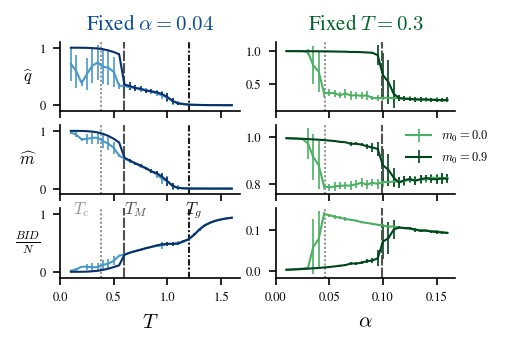

In [39]:
ncols = 2
nrows = 3

T_star = 0.3
a_star = 0.04

width = single_w
figsize= (single_w,0.6*single_w)

set_font_sizes('tight')

fig , axes = plt.subplots(ncols=ncols,nrows=nrows,figsize=figsize,sharex=False)


axes_plot_T = axes[:,0]
# Plot versus T at fixed a_star
T1 = T_crit[np.where(np.isclose(a1,a_star,atol=1e-3))[0][0]]
T2 = T_crit[np.where(np.isclose(a2,a_star,atol=1e-3))[0][0]]
T3 = 1+np.sqrt(a_star)
print(T1,T2,T3)
ida = np.where(np.isclose(alphas,a_star,atol=1e-6))[0][0]
x = temps
for i , ax in enumerate(axes_plot_T):
    norm = N if i==2 else 1 
    # ax.set_ylabel('l',size=40,color='white')
    ax.set_ylim(-0.1,1.1)
    ax.text(-0.18, 0.5, [r'$\widehat{q}$',r'$\widehat{m}$',r'$\frac{BID}{N}$'][i], transform=ax.transAxes, va='center',ha='center' ,bbox=dict(facecolor='white',edgecolor='white', alpha=0.0))
    if i == 2: ax.set_xlabel(r'$T$')
    if i == 0: ax.set_title(r'Fixed $\alpha = '+f'{a_star:.4}$',color=plt.get_cmap(cmaps[0])(0.9))
    for ih , h in enumerate(hs): 
        m = results['means'][ih,:,ida,i]/norm
        s = results['stds'][ih,:,ida,i]/norm

        col = plt.get_cmap(cmaps[0])([0.6,1.0][ih])
        ax.errorbar(x,m,s,label=r'$m_0 = '+f'{h:.2}$',color=col,elinewidth=0.8,lw=1)
    for ic , Tc in enumerate([T1,T2,T3]):
        ax.axvline(Tc,ls=lsts[ic],color=col_crit[ic],lw=1)

# axes_plot_T[1].legend(frameon=False,ncols=1,loc=(0.7,0.35))

axes_plot_a = axes[:,1]
# Plot versus alpha at fixed T_star
alpha1 = a1[np.where(np.isclose(T_crit,T_star,atol=1e-2))[0][0]]
alpha2 = a2[np.where(np.isclose(T_crit,T_star,atol=1e-2))[0][0]]
print(alpha1,alpha2)
idT = np.where(np.isclose(temps,T_star,atol=1e-6))[0][0]
x = alphas
for i , ax in enumerate(axes_plot_a):
    # ax.set_ylim(-0.1,1.1)
    norm = N if i==2 else 1
    if i == 2: ax.set_xlabel(r'$\alpha$')
    if i == 0: ax.set_title(r'Fixed $T = '+f'{T_star:.4}$',color=plt.get_cmap(cmaps[1])(0.9))
    # ax.text(0.05, 0.9, [r'$q$',r'$m$',r'$\frac{BID}{N}$'][i], transform=ax.transAxes, bbox=dict(facecolor='white',edgecolor='white', alpha=0.85))

    # ax.set_ylabel(params[i])
    # if i != 2:
    #     ax.set_ylim(0,1)
    for ih , h in enumerate(hs): 
        m = results['means'][ih,idT,:,i]/norm
        s = results['stds'][ih,idT,:,i]/norm
        col = plt.get_cmap(cmaps[1])([0.6,1.0][ih])
        ax.errorbar(x,m,s,label=r'$m_0 = '+f'{h:.2}$',color=col,elinewidth=0.8,lw=1)
    for ic , ac in enumerate([alpha1,alpha2]):
        print(ic)
        ax.axvline(ac,ls=lsts[ic],color=col_crit[ic],lw=1)

axes_plot_a[1].legend(frameon=False,ncols=1,loc=(0.7,0.35))

for i, ax in enumerate(axes_plot_T):
    ax.set_xticks(tick_num)
    if i != len(axes_plot_T) - 1:
        ax.tick_params(labelbottom=False)
        
for i, ax in enumerate(axes_plot_a):
    ax.set_xticks(tick_num/10)
    if i != len(axes_plot_a) - 1:
        ax.tick_params(labelbottom=False,)

# for pos , lb  in zip([],lbTc):

for ic , pos in enumerate([(0.15,0.32),(0.25,0.32),(0.37,0.32)]):
        fig.text(*pos, lbTc[ic], color = col_crit[ic],size=FONTSIZES['s'])
    
# fname = path_plots + f'Cutting_parameter_space_N{N}_Ns{N_samples}_Nw{N_walkers}_burnin{burnin}_dts{dt_samples}.png'
# fig.savefig(fname, dpi=300, bbox_inches='tight')